# Sequential Graph

1 - Create **multiple nodes** that sequentially process and update different parts of the state

2 - Connect Nodes together in a graph

3 - Invoke the graph and see how the state is transformed

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str


In [10]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    state['final'] = f"Hi {state['name']}!"
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the first node of our sequence"""
    state['final'] = state['final'] + f" You are {state['age']} years old!"
    return state

In [11]:
graph = StateGraph(AgentState)

graph.add_node('first_node', first_node)
graph.add_node('second_node', second_node)

graph.add_edge(START, 'first_node')
graph.add_edge('first_node', 'second_node')
graph.add_edge('second_node', END)

app = graph.compile()

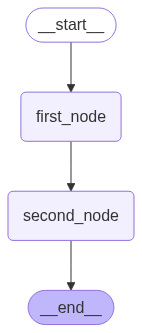

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result = app.invoke({"name": "lineker", "age": 27})
result

{'name': 'lineker', 'age': 27, 'final': 'Hi lineker! You are 27 years old!'}

## Excercise

1 - Accept a user's name, age and a list of their skills

2 - Pass the state through nodes that:

- **First Node**: Personalizes the name field with a greeting
- **Second node**: Describes the user's age
- **Third node**: Lists the user's skills in a formatted string

3 - The final output in the result field should be a combined message.

In [17]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END

In [18]:
class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    final: str

In [23]:
def first_node(state: AgentState) -> AgentState:
    """
    Personalizes the name field with a Greeting

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state['final'] = f'Hi {state['name']} welcome to the System!'
    return state

def second_node(state: AgentState) -> AgentState:
    """
    Describe the user's age

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state['final'] = state['final'] + f' You are {state['age']} years old'
    return state

def third_node(state: AgentState) -> AgentState:
    """
    Lists the user's skills in a formatted string

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state['final'] = state['final'] + f' You have skills in {', '.join(list(map(lambda x: x.title(), state['skills'])))}'
    return state
    
    

In [25]:
graph = StateGraph(AgentState)

graph.add_node('first_node', first_node)
graph.add_node('second_node', second_node)
graph.add_node('third_node', third_node)

graph.add_edge(START, 'first_node')
graph.add_edge('first_node', 'second_node')
graph.add_edge('second_node', 'third_node')
graph.add_edge('third_node', END)

app = graph.compile()

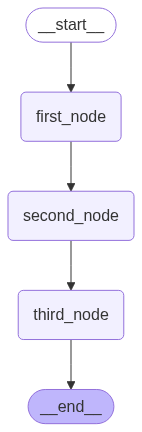

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
result = app.invoke({
    "name": "Lineker",
    "age": "27",
    "skills": ["Python", 'Data science', "SQL"]
})

In [28]:
result

{'name': 'Lineker',
 'age': '27',
 'skills': ['Python', 'Data science', 'SQL'],
 'final': 'Hi Lineker welcome to the System! You are 27 years old You have skills in Python, Data Science, Sql'}

# Conditional Graph

In [29]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    final_number: str

In [31]:
def adder(state: AgentState) -> AgentState:
    """
    This node adds two numbers

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state['final_number'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """
    This node subtract two numbers

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state['final_number'] = state['number1'] - state['number2']
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """
    This node will select the next node of the graph

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    if state['operation'] == "+":
        return 'addition_operation'
    elif state['operation'] == "-":
        return "subtraction_operation"
    

In [32]:
graph = StateGraph(AgentState)

graph.add_node('add_node', adder)
graph.add_node('subtract_node', subtractor)
graph.add_node("router", lambda state:state) # The input and the output will be the same state

graph.add_edge(START, 'router')
graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node" 
    }
)

graph.add_edge('add_node', END)
graph.add_edge('subtract_node', END)
app = graph.compile()

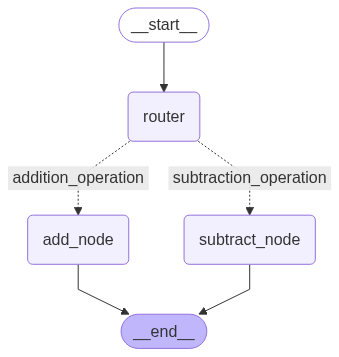

In [33]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [34]:
response = app.invoke({
    'number1': 10,
    'number2': 5,
    'operation': '+'
})
response

{'number1': 10, 'number2': 5, 'operation': '+', 'final_number': 15}

# Looping Grapgh

In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List
from random import randint

In [5]:
class AgentState(TypedDict):
    name: str
    random_numbers: List[int]
    count: int

In [24]:
def greeting_node(state: AgentState) -> AgentState:
    """
    This function says Hello

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state["name"] = f"Hi there, {state["name"]}"
    state["count"] = 0
    return state

def random_node(state: AgentState) -> AgentState:
    """
    This function generates a random number

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    state["random_numbers"].append(randint(a=0, b=100))
    state["count"] += 1
    return state

def control_loop(state: AgentState) -> AgentState:
    """
    Function to control the loop

    Args:
        state (AgentState): _description_

    Returns:
        AgentState: _description_
    """
    if state["count"] < 5:
        print(f"ENTERING THE LOOP {state['count']}")
        return 'continue'
    elif state["count"] >= 5:
        return "exit"

In [29]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)

graph.add_edge(START, "greeting")
graph.add_edge("greeting", "random")
graph.add_conditional_edges(
    "random",
    control_loop,
    {
        "continue": "random",
        "exit": END
    }
)
app = graph.compile()

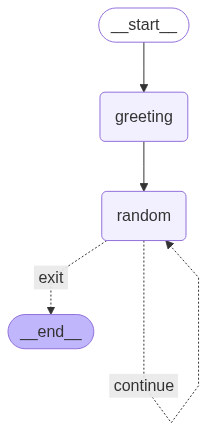

In [30]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [31]:
response = app.invoke({
    "name": "Lineker",
    "random_numbers": [],
    "count": 0
})

ENTERING THE LOOP 1
ENTERING THE LOOP 2
ENTERING THE LOOP 3
ENTERING THE LOOP 4


In [32]:
response

{'name': 'Hi there, Lineker',
 'random_numbers': [85, 68, 69, 3, 37],
 'count': 5}